## UDU vs non-UDU: temporal change analysis

Compare LARIAC building change patterns between known UDU parcels and a matched control sample of single-family residences.

**Source**: `data/04_results/lariac_symdiff.gpkg` (output of `01_lariac_symdiff.ipynb`)

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

os.chdir('../..')

from src.geoadmin import load_neighborhoods, load_laraic


SYMDIFF_PATH       = 'data/04_results/lariac_symdiff.gpkg'
MASTER_PATH        = 'data/processed/assessor_lariac.gpkg'
UDU_PATH           = 'data/01_raw/UDU Report 02_10_2026.csv'
CENSUS_TRACTS_PATH = 'data/03_processed/assessor_udu_tracts.gpkg'


def normalize_ain(s):
    return str(s).strip().replace('-', '')

### 1. UDU count by neighborhood

In [2]:
udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = set(
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
print(f'{len(udu_ains):,} UDU AINs loaded')

442 UDU AINs loaded


In [14]:
symdiff_udu.head()

,AIN,area_2014,area_2017,n_2014,n_2017,area_net,n_delta,epoch,neighborhood,shift_dx_m,shift_dy_m,change_type,area_2020,n_2020,geometry,group,is_udu
0,5213001031,228.577506,170.232955,3.0,3,-51.672297,0,2014→2017,El Sereno,1.092,-0.551,reduced,NaN,NaN,"MULTIPOLYGON (((6507555.593 1854360.095, 65075...",UDU,True
1,5214007011,0.000000,178.336016,0.0,1,178.336016,1,2014→2017,El Sereno,1.092,-0.551,new_parcel,NaN,NaN,"MULTIPOLYGON (((6504055.816 1851945.802, 65039...",UDU,True
2,5218008025,209.791523,209.791545,2.0,2,0.000000,0,2014→2017,El Sereno,1.092,-0.551,no_change,NaN,NaN,"MULTIPOLYGON (((6508739.868 1854093.005, 65087...",UDU,True
3,5307013011,316.435508,316.435767,2.0,2,0.000000,0,2014→2017,El Sereno,1.092,-0.551,no_change,NaN,NaN,"MULTIPOLYGON (((6509348.187 1855133.325, 65094...",UDU,True
4,5307014013,208.381436,208.382340,1.0,1,0.000000,0,2014→2017,El Sereno,1.092,-0.551,no_change,NaN,NaN,"MULTIPOLYGON (((6509625.205 1854964.448, 65096...",UDU,True


In [3]:
from src.geoadmin import load_neighborhoods

hoods = load_neighborhoods().to_crs(4326)

udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = (
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
# load parcel geometries for all UDU AINs from master (2017 layer)
udu_parcels = gpd.read_file(
    'data/processed/assessor_lariac.gpkg', layer='2017',
    columns=['AIN', 'geometry']
)
udu_parcels['AIN'] = udu_parcels['AIN'].apply(normalize_ain)
udu_parcels = udu_parcels[udu_parcels['AIN'].isin(udu_ains)].to_crs(4326)

# spatial join parcel centroids → neighborhood
centroids = udu_parcels.set_geometry(udu_parcels.centroid)
joined = gpd.sjoin(centroids[['AIN', 'geometry']],
                   hoods[['name', 'geometry']],
                   how='left', predicate='within')

udu_by_hood = (
    joined.groupby('name').size()
    .reset_index(name='udu_count')
    .sort_values('udu_count', ascending=False)
    .reset_index(drop=True)
)
print(f"Matched {joined['name'].notna().sum()} / {len(joined)} UDU parcels to a neighborhood")
udu_by_hood[udu_by_hood['udu_count'] > 0]

Matched 439 / 439 UDU parcels to a neighborhood


/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_79645/2941173045.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = udu_parcels.set_geometry(udu_parcels.centroid)


,name,udu_count
0,Venice,26
1,Boyle Heights,23
2,San Pedro,18
3,Hollywood,15
4,Historic South-Central,14
...,...,...
81,Sun Valley,1
82,Pacific Palisades,1
83,Chesterfield Square,1
84,Chinatown,1


### 3. Load symdiff — all UDU parcels

In [4]:
ain_sql   = "','".join(sorted(udu_ains))
symdiff_udu = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql}')")
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
symdiff_udu['AIN']    = symdiff_udu['AIN'].apply(normalize_ain)
symdiff_udu['group']  = 'UDU'
symdiff_udu['is_udu'] = symdiff_udu['AIN'].isin(udu_ains)

print(f"UDU: {symdiff_udu['AIN'].nunique()} AINs  |  {len(symdiff_udu):,} rows")
symdiff_udu.groupby(['epoch','change_type']).size().unstack(fill_value=0)

UDU: 377 AINs  |  688 rows


change_type,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,,
2014→2017,2,0,8,4,302,3,6
2017→2020,1,1,5,0,332,18,6


### 4. Load symdiff — SFR control sample (census-tract restricted)
Non-UDU single-family residential parcels from tracts containing at least one UDU and a mix of residential types (output of `05_census_control.ipynb`).

In [5]:
# Load SFR control from census-tract subset (05_census_control output)
ct_parcels = gpd.read_file(
    CENSUS_TRACTS_PATH, layer='parcels',
    columns=['AIN', 'res_category', 'is_udu'],
    read_geometry=False,
)
ct_parcels['AIN'] = ct_parcels['AIN'].apply(normalize_ain)

sfr_sample = set(
    ct_parcels.loc[
        (ct_parcels['res_category'] == 'sfr') & (~ct_parcels['is_udu']),
        'AIN'
    ]
)
print(f"{len(sfr_sample):,} non-UDU SFR AINs in census-tract-restricted sample")

ain_sql_sfr = "','".join(sorted(sfr_sample))
symdiff_sfr = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql_sfr}')")
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
symdiff_sfr['AIN']    = symdiff_sfr['AIN'].apply(normalize_ain)
symdiff_sfr['group']  = 'SFR (non-UDU)'
symdiff_sfr['is_udu'] = symdiff_sfr['AIN'].isin(udu_ains)

print(f"SFR sample: {symdiff_sfr['AIN'].nunique()} AINs  |  {len(symdiff_sfr):,} rows")
symdiff_sfr.groupby(['epoch', 'change_type']).size().unstack(fill_value=0)

94,611 non-UDU SFR AINs in census-tract-restricted sample
SFR sample: 74947 AINs  |  136,592 rows


change_type,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,,
2014→2017,1490,493,3278,997,55179,1519,1415
2017→2020,894,276,3593,312,63136,2407,1603


### 5. Change type breakdown: UDU vs SFR control
Proportion of each change class per group, per epoch.

Saved → notebooks/tasks/figures/udu_change_type_proportions.png


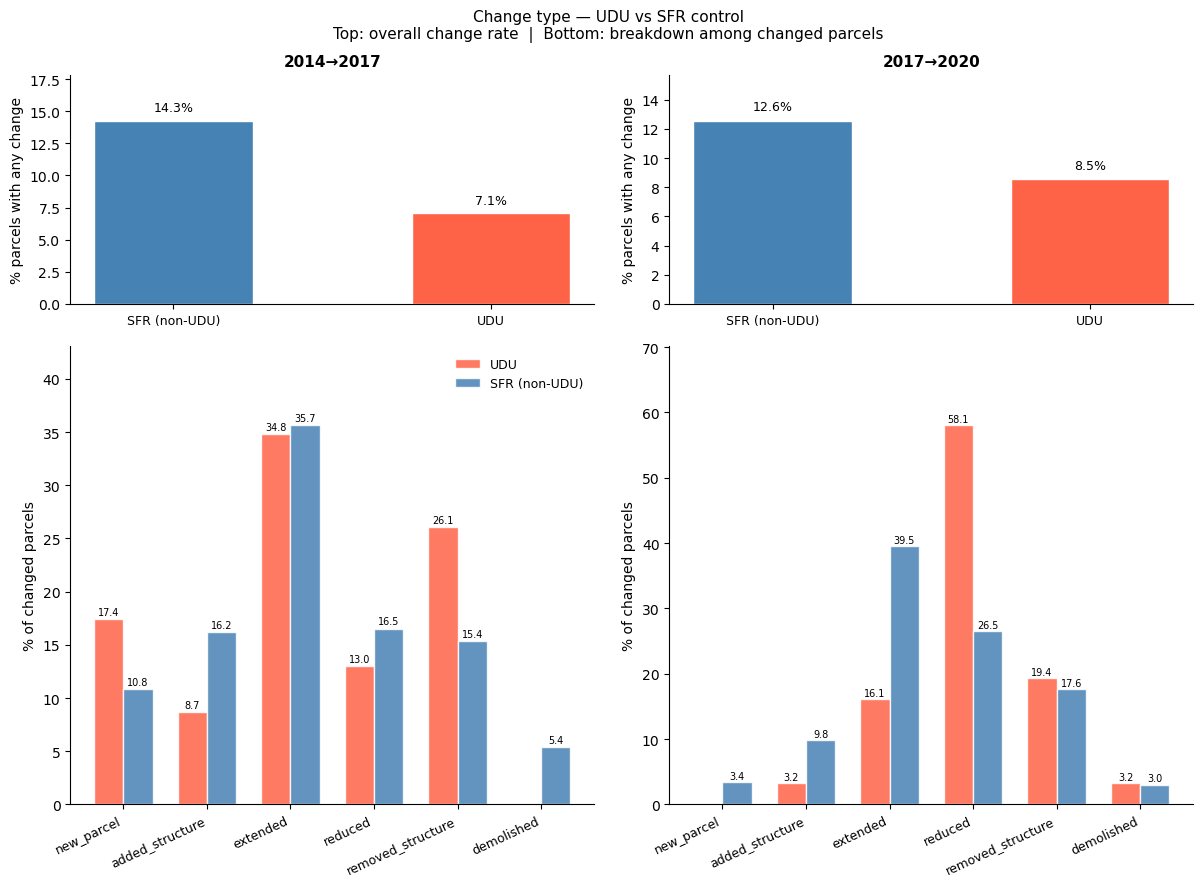

In [15]:
symdiff = pd.concat([symdiff_udu, symdiff_sfr], ignore_index=True)

CHANGE_TYPES = ['new_parcel', 'added_structure', 'extended',
                'reduced', 'removed_structure', 'demolished']
COLORS = {
    'UDU':           'tomato',
    'SFR (non-UDU)': 'steelblue',
}

epochs = sorted(symdiff['epoch'].unique())
fig, axes = plt.subplots(2, len(epochs), figsize=(6 * len(epochs), 9),
                         gridspec_kw={'height_ratios': [1, 2]})

for col, epoch in enumerate(epochs):
    sub = symdiff[symdiff['epoch'] == epoch].copy()
    sub['changed'] = sub['change_type'] != 'no_change'

    # ── row 0: overall change rate ────────────────────────────────────────────
    ax0 = axes[0, col]
    rates = sub.groupby('group')['changed'].mean() * 100
    bars = ax0.bar(rates.index, rates.values,
                   color=[COLORS[g] for g in rates.index],
                   width=0.5, edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax0.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax0.set_title(epoch, fontsize=11, fontweight='bold')
    ax0.set_ylabel('% parcels with any change')
    ax0.set_ylim(0, rates.max() * 1.25)
    ax0.set_xticks(range(len(rates)))
    ax0.set_xticklabels(rates.index, fontsize=9)
    ax0.spines[['top', 'right']].set_visible(False)

    # ── row 1: breakdown among changed parcels only ───────────────────────────
    ax1 = axes[1, col]
    changed = sub[sub['changed']]
    present = [c for c in CHANGE_TYPES if c in changed['change_type'].values]

    x = np.arange(len(present))
    width = 0.35
    for i, (group, color) in enumerate(COLORS.items()):
        g = changed[changed['group'] == group]
        total = len(g)
        vals = [100 * (g['change_type'] == ct).sum() / total if total else 0
                for ct in present]
        offset = (i - 0.5) * width
        bars2 = ax1.bar(x + offset, vals, width=width,
                        color=color, alpha=0.85, label=group, edgecolor='white')
        for bar, val in zip(bars2, vals):
            if val > 0.5:
                ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                         f'{val:.1f}', ha='center', va='bottom', fontsize=7)

    ax1.set_xticks(x)
    ax1.set_xticklabels(present, rotation=25, ha='right', fontsize=9)
    ax1.set_ylabel('% of changed parcels')
    ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)
    ax1.spines[['top', 'right']].set_visible(False)
    if col == 0:
        ax1.legend(fontsize=9, frameon=False)

plt.suptitle('Change type — UDU vs SFR control\n'
             'Top: overall change rate  |  Bottom: breakdown among changed parcels',
             fontsize=11)
plt.tight_layout()

OUT_FIG = 'notebooks/tasks/figures/udu_change_type_proportions.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


### Net area change distribution

is_udu     non-UDU  UDU
epoch                  
2014→2017     7702   19
2017→2020     8497   30


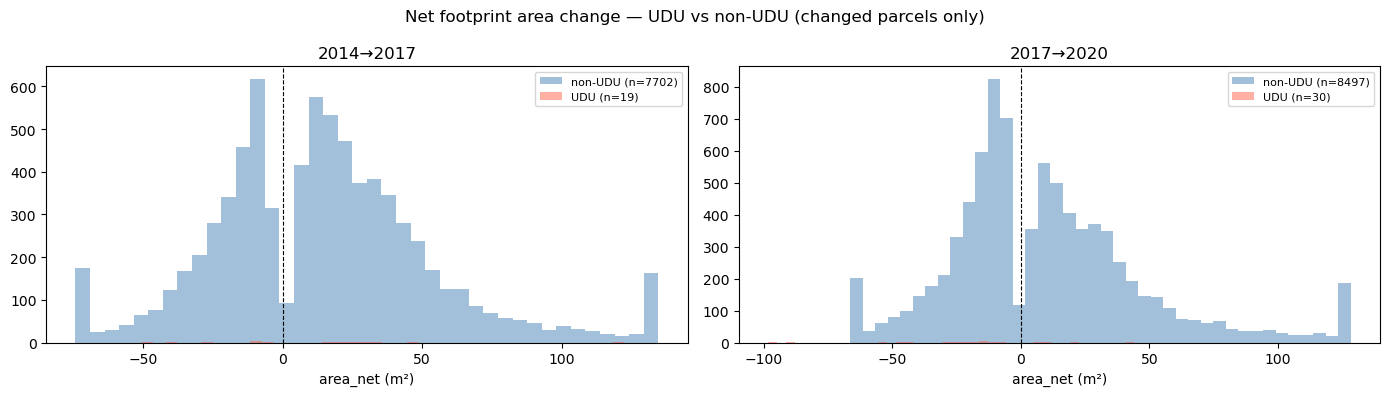

In [16]:
focus_types = ['added_structure', 'extended', 'reduced', 'removed_structure']
sub = symdiff[symdiff['change_type'].isin(focus_types)]

# diagnostic — show how many records per group
print(sub.groupby(['epoch', 'is_udu']).size().unstack(fill_value=0).rename(columns={False:'non-UDU', True:'UDU'}))

epochs = sorted(sub['epoch'].unique())
fig, axes = plt.subplots(1, len(epochs), figsize=(7 * len(epochs), 4), sharey=False)
if len(epochs) == 1:
    axes = [axes]

for ax, epoch in zip(axes, epochs):
    ep = sub[sub['epoch'] == epoch]
    has_data = False
    for flag, color, name in [(False, 'steelblue', 'non-UDU'), (True, 'tomato', 'UDU')]:
        vals = ep.loc[ep['is_udu'] == flag, 'area_net'].dropna()
        if len(vals) < 2:
            ax.text(0.5, 0.5, f'no {name} data', transform=ax.transAxes,
                    ha='center', va='center', color=color, fontsize=9)
            continue
        lo, hi = vals.quantile(0.02), vals.quantile(0.98)
        if lo == hi:
            lo, hi = vals.min(), vals.max()
        if lo == hi:   # all identical values — just mark with vline
            ax.axvline(lo, color=color, linewidth=2, label=f'{name} (n={len(vals)})')
            continue
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.5,
                color=color, label=f'{name} (n={len(vals)})')
        has_data = True
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('area_net (m²)')
    ax.legend(fontsize=8)

plt.suptitle('Net footprint area change — UDU vs non-UDU (changed parcels only)', fontsize=12)
plt.tight_layout()
plt.show()

### Building count delta

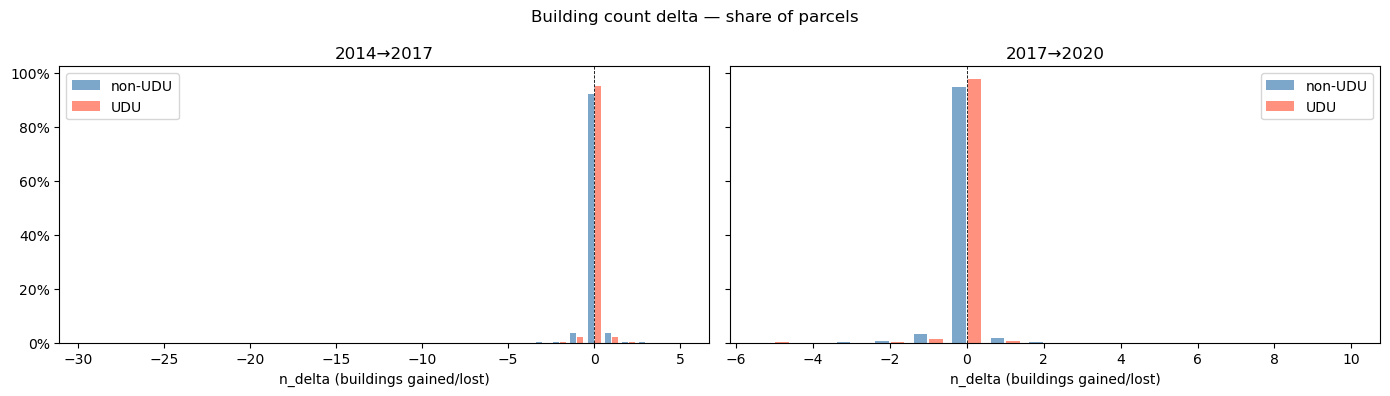

In [17]:
delta_counts = (
    symdiff
    .groupby(['epoch', 'is_udu', 'n_delta'])
    .size()
    .reset_index(name='count')
)
delta_counts['share'] = delta_counts.groupby(['epoch', 'is_udu'])['count'].transform(lambda x: x / x.sum())
delta_counts['group'] = delta_counts['is_udu'].map({True: 'UDU', False: 'non-UDU'})

epochs = sorted(delta_counts['epoch'].unique())
fig, axes = plt.subplots(1, len(epochs), figsize=(7 * len(epochs), 4), sharey=True)
if len(epochs) == 1:
    axes = [axes]

for ax, epoch in zip(axes, epochs):
    ep = delta_counts[delta_counts['epoch'] == epoch]
    for group, color in [('non-UDU', 'steelblue'), ('UDU', 'tomato')]:
        g = ep[ep['group'] == group].sort_values('n_delta')
        ax.bar(g['n_delta'] + (0.2 if group == 'UDU' else -0.2),
               g['share'], width=0.35, alpha=0.7, color=color, label=group)
    ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('n_delta (buildings gained/lost)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend()

plt.suptitle('Building count delta — share of parcels', fontsize=12)
plt.tight_layout()
plt.show()

### Summary table

In [18]:
summary = (
    symdiff
    .groupby(['epoch', 'is_udu', 'change_type'])
    .size()
    .reset_index(name='n')
)
summary['pct'] = summary.groupby(['epoch', 'is_udu'])['n'].transform(lambda x: 100 * x / x.sum())
(summary
 .pivot_table(index=['epoch', 'change_type'], columns='is_udu', values='pct')
 .rename(columns={False: 'non-UDU %', True: 'UDU %'})
 .round(1)
)

is_udu                       non-UDU %  UDU %
epoch     change_type                        
2014→2017 added_structure          2.3    0.6
          demolished               0.8    NaN
          extended                 5.1    2.5
          new_parcel               1.5    1.2
          no_change               85.7   92.9
          reduced                  2.4    0.9
          removed_structure        2.2    1.8
2017→2020 added_structure          1.2    0.3
          demolished               0.4    0.3
          extended                 5.0    1.4
          new_parcel               0.4    NaN
          no_change               87.4   91.5
          reduced                  3.3    5.0
          removed_structure        2.2    1.7

In [39]:
from shapely.ops import unary_union

EPOCH_KEY   = {'2014→2017': '2014_2017', '2017→2020': '2017_2020'}
EPOCH_YEARS = {'2014→2017': (2014, 2017), '2017→2020': (2017, 2020)}


def load_delta_geoms(epoch, ains, kind='added'):
    """Load pre-computed added or removed geometry from GPKG for a set of AINs.
    Returns dict {AIN: geometry} in the GPKG's native CRS.
    """
    layer   = f'{kind}_{EPOCH_KEY[epoch]}'
    ain_sql = "','".join(sorted(ains))
    gdf = gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql}')")
    if gdf.empty:
        return {}
    gdf['AIN'] = gdf['AIN'].apply(normalize_ain)
    return gdf.dissolve(by='AIN')['geometry'].to_dict()


def load_footprints_for_ains(parcel_gdf, yr):
    """Load LARIAC building footprints clipped to parcel boundaries for a set of AINs.

    Delegates to load_laraic() for file path / CRS handling, then spatially
    joins buildings to parcels, clips each to its parcel, and dissolves per AIN.

    Parameters
    ----------
    parcel_gdf : GeoDataFrame with columns ['AIN', 'geometry'] (parcel polygons)
    yr         : int, one of 2014, 2017, 2020

    Returns
    -------
    dict {AIN: dissolved footprint geometry}  in parcel_gdf.crs
    """
    lar = load_laraic(parcel_gdf, yr)
    lar = lar[lar['CODE'] == 'Building'][['geometry']].reset_index(drop=True)

    if lar.empty:
        return {}

    parcels = parcel_gdf.set_index('AIN')['geometry']
    joined  = gpd.sjoin(lar, parcel_gdf[['AIN', 'geometry']],
                        how='inner', predicate='intersects')

    result = {}
    for ain, group in joined.groupby('AIN'):
        if ain not in parcels.index:
            continue
        clipped = group.geometry.intersection(parcels[ain])
        clipped = clipped[~clipped.is_empty]
        if not clipped.empty:
            result[ain] = unary_union(clipped)
    return result


In [40]:
reduced = (symdiff_udu[symdiff_udu['change_type'] == 'reduced']
           [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
           .drop_duplicates('AIN')
           .reset_index(drop=True))

print(f"{len(reduced)} reduced UDU parcels across {reduced['neighborhood'].nunique()} neighborhoods")
reduced[['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta']]

21 reduced UDU parcels across 16 neighborhoods


,AIN,neighborhood,epoch,area_net,n_delta
0,5213001031,El Sereno,2014→2017,-51.672297,0
1,5104018027,Central-Alameda,2014→2017,-9.368256,0
2,5119027018,Central-Alameda,2014→2017,-25.921926,0
3,5516026008,Koreatown,2017→2020,-14.498637,0
4,5175023031,Boyle Heights,2017→2020,-43.870532,0
5,5532001024,Hollywood,2017→2020,-27.759206,0
6,5544005011,Hollywood,2017→2020,-88.621274,0
7,4006005028,Hyde Park,2017→2020,-18.972568,0
8,6038009006,Vermont Vista,2017→2020,-20.515129,0
9,5527038029,Fairfax,2017→2020,-45.038014,0


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib

Saved → notebooks/tasks/figures/udu_reduced_footprint_diff.png


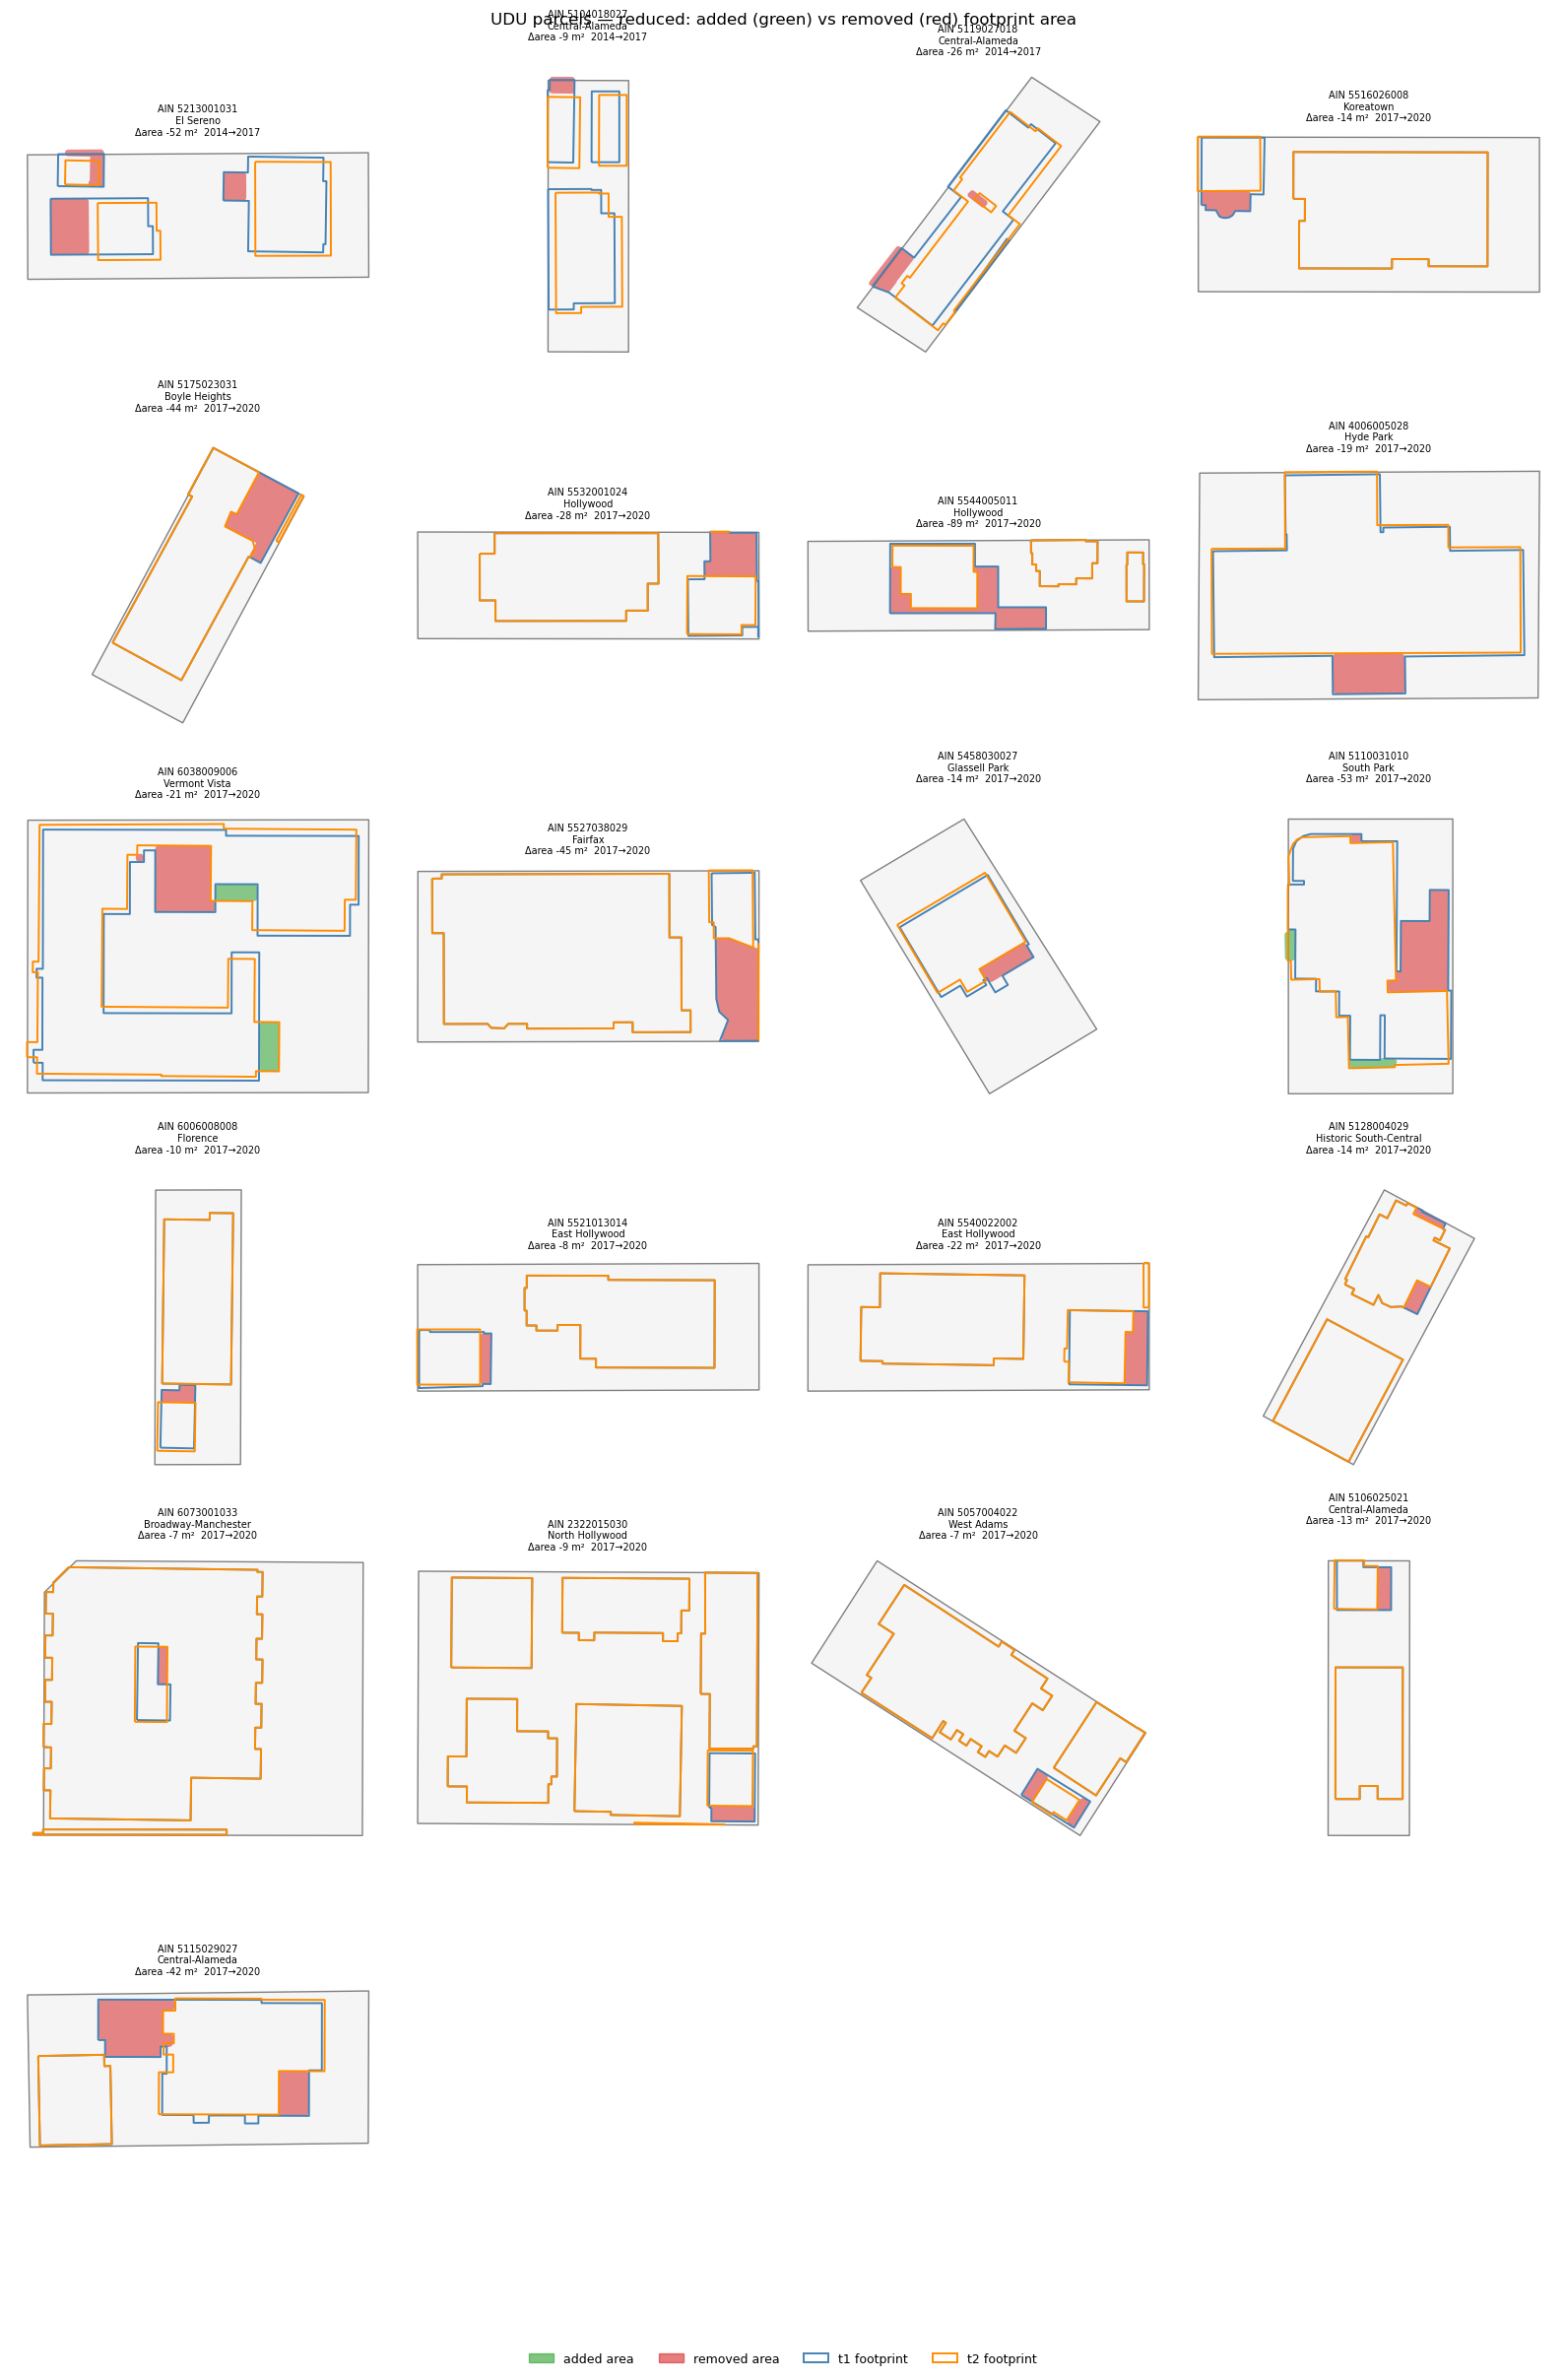

In [41]:
# pre-load delta geoms and LARIAC footprints for all reduced UDU AINs
reduced_ains = set(reduced['AIN'])
added_by_epoch_rd   = {ep: load_delta_geoms(ep, reduced_ains, 'added')
                       for ep in reduced['epoch'].unique()}
removed_by_epoch_rd = {ep: load_delta_geoms(ep, reduced_ains, 'removed')
                       for ep in reduced['epoch'].unique()}

fp_t1_rd, fp_t2_rd = {}, {}
for epoch, (yr1, yr2) in EPOCH_YEARS.items():
    sub = reduced[reduced['epoch'] == epoch][['AIN', 'geometry']].copy()
    if sub.empty:
        continue
    fp_t1_rd[epoch] = load_footprints_for_ains(sub, yr1)
    fp_t2_rd[epoch] = load_footprints_for_ains(sub, yr2)

n = len(reduced)
n_cols = min(4, n)
n_rows = -(-n // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, reduced.iterrows()):
    ain   = row['AIN']
    epoch = row['epoch']
    crs   = reduced.crs

    added_area   = added_by_epoch_rd[epoch].get(ain)
    removed_area = removed_by_epoch_rd[epoch].get(ain)
    fp1          = fp_t1_rd.get(epoch, {}).get(ain)
    fp2          = fp_t2_rd.get(epoch, {}).get(ain)

    # parcel background
    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    # delta fills
    if added_area and not added_area.is_empty:
        gpd.GeoSeries([added_area], crs=crs).plot(
            ax=ax, facecolor='#2ca02c', alpha=0.55, edgecolor='none')
    if removed_area and not removed_area.is_empty:
        gpd.GeoSeries([removed_area], crs=crs).plot(
            ax=ax, facecolor='#d62728', alpha=0.55, edgecolor='none')

    # footprint outlines: t1 = blue, t2 = orange
    for fp, color in [(fp1, 'steelblue'), (fp2, 'darkorange')]:
        if fp is not None and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.4)

    ax.set_title(
        f'AIN {ain}\n{row["neighborhood"]}\n'
        f'Δarea {row["area_net"]:+.0f} m²  {epoch}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='added area'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='removed area'),
    mpatches.Patch(edgecolor='steelblue',  facecolor='none', linewidth=1.4, label='t1 footprint'),
    mpatches.Patch(edgecolor='darkorange', facecolor='none', linewidth=1.4, label='t2 footprint'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — reduced: added (green) vs removed (red) footprint area', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_reduced_footprint_diff.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


In [ ]:
removed_struct = (symdiff_udu[symdiff_udu['change_type'] == 'removed_structure']
                  [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
                  .drop_duplicates('AIN')
                  .reset_index(drop=True))

print(f"{len(removed_struct)} removed_structure UDU parcels")
print(removed_struct['neighborhood'].value_counts())

rs_ains = set(removed_struct['AIN'])
removed_by_epoch_rs = {ep: load_delta_geoms(ep, rs_ains, 'removed')
                       for ep in removed_struct['epoch'].unique()}

fp_t1_rs, fp_t2_rs = {}, {}
for epoch, (yr1, yr2) in EPOCH_YEARS.items():
    sub = removed_struct[removed_struct['epoch'] == epoch][['AIN', 'geometry']].copy()
    if sub.empty:
        continue
    fp_t1_rs[epoch] = load_footprints_for_ains(sub, yr1)
    fp_t2_rs[epoch] = load_footprints_for_ains(sub, yr2)

n = len(removed_struct)
n_cols = min(4, n)
n_rows = -(-n // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, removed_struct.iterrows()):
    ain   = row['AIN']
    epoch = row['epoch']
    crs   = removed_struct.crs

    removed_area = removed_by_epoch_rs[epoch].get(ain)
    fp1          = fp_t1_rs.get(epoch, {}).get(ain)
    fp2          = fp_t2_rs.get(epoch, {}).get(ain)

    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    if removed_area and not removed_area.is_empty:
        gpd.GeoSeries([removed_area], crs=crs).plot(
            ax=ax, facecolor='#d62728', alpha=0.5, edgecolor='none')

    for fp, color in [(fp1, 'steelblue'), (fp2, 'darkorange')]:
        if fp is not None and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.4)

    ax.set_title(
        f'AIN {ain}\n{row["neighborhood"]}\nΔarea {row["area_net"]:+.0f} m²  {epoch}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(color='#d62728', alpha=0.6, label='removed area'),
    mpatches.Patch(edgecolor='steelblue',  facecolor='none', linewidth=1.4, label='t1 footprint'),
    mpatches.Patch(edgecolor='darkorange', facecolor='none', linewidth=1.4, label='t2 footprint'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — removed structure: removed footprint area (red)', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_removed_structure.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


12 removed_structure UDU parcels
neighborhood
Echo Park          2
Central-Alameda    2
Harbor City        1
Hollywood          1
East Hollywood     1
El Sereno          1
Vermont Vista      1
Pico-Union         1
North Hollywood    1
Jefferson Park     1
Name: count, dtype: int64


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib

In [ ]:
extended_udu = (symdiff_udu[symdiff_udu['change_type'] == 'extended']
                [['AIN', 'neighborhood', 'epoch', 'area_net', 'n_delta', 'geometry']]
                .drop_duplicates('AIN')
                .reset_index(drop=True))

print(f"{len(extended_udu)} extended UDU parcels")
print(extended_udu['neighborhood'].value_counts())

ex_ains = set(extended_udu['AIN'])
added_by_epoch_ex = {ep: load_delta_geoms(ep, ex_ains, 'added')
                     for ep in extended_udu['epoch'].unique()}

fp_t1_ex, fp_t2_ex = {}, {}
for epoch, (yr1, yr2) in EPOCH_YEARS.items():
    sub = extended_udu[extended_udu['epoch'] == epoch][['AIN', 'geometry']].copy()
    if sub.empty:
        continue
    fp_t1_ex[epoch] = load_footprints_for_ains(sub, yr1)
    fp_t2_ex[epoch] = load_footprints_for_ains(sub, yr2)

n = len(extended_udu)
n_cols = min(4, n)
n_rows = -(-n // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, extended_udu.iterrows()):
    ain   = row['AIN']
    epoch = row['epoch']
    crs   = extended_udu.crs

    added_area = added_by_epoch_ex[epoch].get(ain)
    fp1        = fp_t1_ex.get(epoch, {}).get(ain)
    fp2        = fp_t2_ex.get(epoch, {}).get(ain)

    if row.geometry and not row.geometry.is_empty:
        gpd.GeoSeries([row.geometry], crs=crs).plot(
            ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

    if added_area and not added_area.is_empty:
        gpd.GeoSeries([added_area], crs=crs).plot(
            ax=ax, facecolor='#2ca02c', alpha=0.6, edgecolor='none')

    for fp, color in [(fp1, 'steelblue'), (fp2, 'darkorange')]:
        if fp is not None and not fp.is_empty:
            gpd.GeoSeries([fp], crs=crs).boundary.plot(
                ax=ax, edgecolor=color, linewidth=1.4)

    ax.set_title(
        f'AIN {ain}\n{row["neighborhood"]}\nΔarea {row["area_net"]:+.0f} m²  {epoch}',
        fontsize=7
    )
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

patches = [
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='added area'),
    mpatches.Patch(edgecolor='steelblue',  facecolor='none', linewidth=1.4, label='t1 footprint'),
    mpatches.Patch(edgecolor='darkorange', facecolor='none', linewidth=1.4, label='t2 footprint'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('UDU parcels — extended: added footprint area (green)', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT_FIG = 'notebooks/tasks/figures/udu_extended.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


### Shadow additions — SFR parcels with footprint growth but no assessor update
Positive LARIAC area change (`added_structure`, `extended`, `new_parcel`, `area_net > 0`) but `assr_sqftmain` (assessor recorded sq ft) unchanged between epochs → candidate unpermitted addition.

10564 positive-change SFR rows across 10117 AINs
change_type  added_structure  extended  new_parcel
epoch                                             
2014→2017               1490      3278         997
2017→2020                894      3593         312

Shadow additions: 8632 / 10564 (81.7%) positive-change SFR parcels
shadow     False  True 
epoch                  
2014→2017    785   4980
2017→2020   1147   3652
Saved → notebooks/tasks/figures/sfr_shadow_additions.png


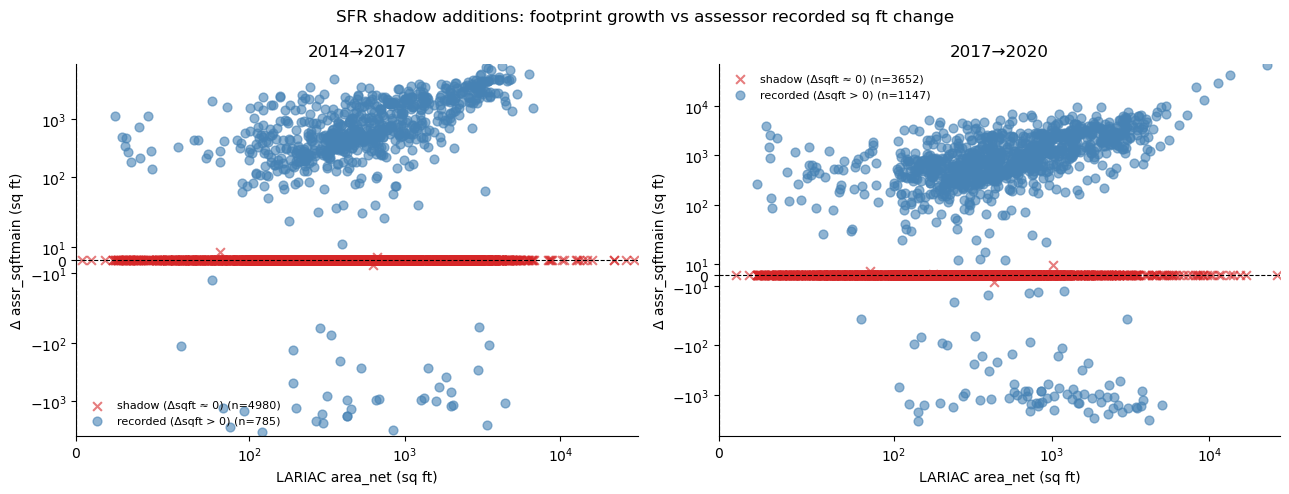

n  median_area_net_sqft
epoch     shadow change_type                                
2014→2017 False  added_structure    85                 841.8
                 extended          513                 398.5
                 new_parcel        187                1960.7
          True   added_structure  1405                 442.2
                 extended         2765                 235.0
                 new_parcel        810                2207.8
2017→2020 False  added_structure   167                 923.0
                 extended          819                 383.1
                 new_parcel        161                2588.0
          True   added_structure   727                 429.1
                 extended         2774                 198.5
                 new_parcel        151                2074.4

In [ ]:
EPOCH_YRS  = {'2014→2017': (2014, 2017), '2017→2020': (2017, 2020)}
POS_TYPES  = ['added_structure', 'extended', 'new_parcel']
M2_TO_SQFT = 10.7639

# positive-change SFR rows
sfr_pos = (symdiff_sfr[
    symdiff_sfr['change_type'].isin(POS_TYPES) & (symdiff_sfr['area_net'] > 0)
][['AIN', 'epoch', 'change_type', 'area_net', 'n_delta']]
.copy().reset_index(drop=True))

print(f"{len(sfr_pos)} positive-change SFR rows across {sfr_pos['AIN'].nunique()} AINs")
print(sfr_pos.groupby(['epoch', 'change_type']).size().unstack(fill_value=0))

# ── load assr_sqftmain for t1 and t2 per epoch ───────────────────────────────
def load_assr_sqft(ains, layer_yr):
    ain_sql = "','".join(sorted(ains))
    df = gpd.read_file(
        MASTER_PATH, layer=str(layer_yr),
        columns=['AIN', 'assr_sqftmain'],
        where=f"AIN IN ('{ain_sql}')",
        read_geometry=False,
    )
    df['AIN'] = df['AIN'].apply(normalize_ain)
    return df.set_index('AIN')['assr_sqftmain']

records = []
for epoch, (yr1, yr2) in EPOCH_YRS.items():
    sub = sfr_pos[sfr_pos['epoch'] == epoch]
    if sub.empty:
        continue
    ains = set(sub['AIN'])
    sqft1 = load_assr_sqft(ains, yr1)
    sqft2 = load_assr_sqft(ains, yr2)

    for _, row in sub.iterrows():
        ain = row['AIN']
        s1  = sqft1.get(ain, np.nan)
        s2  = sqft2.get(ain, np.nan)
        records.append({
            **row.to_dict(),
            'area_net_sqft':   row['area_net'] * M2_TO_SQFT,
            'assr_sqft_t1':    s1,
            'assr_sqft_t2':    s2,
            'delta_assr_sqft': (s2 - s1) if pd.notna(s1) and pd.notna(s2) else np.nan,
        })

shadow_df = pd.DataFrame(records)

# shadow flag: footprint grew but assessor sq ft didn't increase
SQFT_THRESHOLD = 10   # sq ft — noise tolerance
shadow_df['shadow'] = (
    shadow_df['delta_assr_sqft'].fillna(0).abs() < SQFT_THRESHOLD
)

n_shadow = shadow_df['shadow'].sum()
n_total  = len(shadow_df)
print(f"\nShadow additions: {n_shadow} / {n_total} "
      f"({100*n_shadow/n_total:.1f}%) positive-change SFR parcels")
print(shadow_df.groupby(['epoch', 'shadow']).size().unstack(fill_value=0))

# ── scatter: area_net_sqft vs delta_assr_sqft (both in sq ft) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, epoch in zip(axes, sorted(shadow_df['epoch'].unique())):
    ep = shadow_df[shadow_df['epoch'] == epoch]
    for is_shadow, color, label, marker in [
        (True,  '#d62728', 'shadow (Δsqft ≈ 0)', 'x'),
        (False, 'steelblue', 'recorded (Δsqft > 0)', 'o'),
    ]:
        g = ep[ep['shadow'] == is_shadow]
        ax.scatter(
            g['area_net_sqft'],
            g['delta_assr_sqft'].fillna(0),
            c=color, alpha=0.6, s=40,
            marker=marker, label=f'{label} (n={len(g)})',
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('LARIAC area_net (sq ft)')
    ax.set_ylabel('Δ assr_sqftmain (sq ft)')
    ax.set_title(epoch)
    ax.set_xscale('symlog', linthresh=100), ax.set_xlim(0, None)
    ax.set_yscale('symlog', linthresh=50)

    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('SFR shadow additions: footprint growth vs assessor recorded sq ft change',
             fontsize=12)
plt.tight_layout()

OUT_FIG = 'notebooks/tasks/figures/sfr_shadow_additions.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
(shadow_df
 .groupby(['epoch', 'shadow', 'change_type'])
 .agg(n=('AIN', 'count'), median_area_net_sqft=('area_net_sqft', 'median'))
 .round(1)
)

### Shadow additions — example parcels by epoch × shadow flag
Green fill = added footprint area (fp2 − fp1). Blue outline = t1, orange outline = t2.

In [ ]:
N_EXAMPLES = 3
rng_ex = np.random.default_rng(7)

shadow_geo = shadow_df.merge(
    symdiff_sfr[['AIN', 'epoch', 'neighborhood', 'geometry']],
    on=['AIN', 'epoch'], how='left'
)
shadow_geo = gpd.GeoDataFrame(shadow_geo, geometry='geometry', crs=symdiff_sfr.crs)

if 'area_net_sqft' not in shadow_geo.columns:
    shadow_geo['area_net_sqft'] = shadow_geo['area_net'] * 10.7639

COMBOS = [
    ('2014→2017', True,  'shadow'),
    ('2014→2017', False, 'recorded'),
    ('2017→2020', True,  'shadow'),
    ('2017→2020', False, 'recorded'),
]

# ── pick samples first so we only load footprints for displayed AINs ──────────
rng_ex2 = np.random.default_rng(7)   # fresh generator with same seed
samples_by_combo = {}
for combo in COMBOS:
    epoch, is_shadow, label = combo
    pool = shadow_geo[(shadow_geo['epoch'] == epoch) & (shadow_geo['shadow'] == is_shadow)]
    pool = pool.dropna(subset=['neighborhood', 'geometry'])
    idx  = rng_ex2.choice(len(pool), size=min(N_EXAMPLES, len(pool)), replace=False)
    samples_by_combo[combo] = pool.iloc[idx].reset_index(drop=True)

# ── load added geoms and footprints for sampled AINs only ────────────────────
sh_added = {ep: load_delta_geoms(ep, set(shadow_geo['AIN']), 'added')
            for ep in shadow_geo['epoch'].unique()}

sh_fp_t1, sh_fp_t2 = {}, {}
for combo in COMBOS:
    epoch, _, _ = combo
    if epoch in sh_fp_t1:
        continue
    yr1, yr2 = EPOCH_YEARS[epoch]
    all_sampled = pd.concat([samples_by_combo[c] for c in COMBOS if c[0] == epoch])
    parcel_sub  = all_sampled[['AIN', 'geometry']].drop_duplicates('AIN').copy()
    sh_fp_t1[epoch] = load_footprints_for_ains(parcel_sub, yr1)
    sh_fp_t2[epoch] = load_footprints_for_ains(parcel_sub, yr2)

# ── plot ─────────────────────────────────────────────────────────────────────
n_rows = len(COMBOS)
n_cols = N_EXAMPLES
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for row_i, combo in enumerate(COMBOS):
    epoch, is_shadow, label = combo
    sample = samples_by_combo[combo]

    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        ax.axis('off')
        if col_i >= len(sample):
            continue

        row = sample.iloc[col_i]
        ain = row['AIN']
        crs = shadow_geo.crs

        added_area = sh_added[epoch].get(ain)
        fp1        = sh_fp_t1[epoch].get(ain)
        fp2        = sh_fp_t2[epoch].get(ain)

        if row.geometry and not row.geometry.is_empty:
            gpd.GeoSeries([row.geometry], crs=crs).plot(
                ax=ax, facecolor='#f5f5f5', edgecolor='gray', linewidth=1)

        if added_area and not added_area.is_empty:
            gpd.GeoSeries([added_area], crs=crs).plot(
                ax=ax, facecolor='#2ca02c', alpha=0.6, edgecolor='none')

        for fp, color in [(fp1, 'steelblue'), (fp2, 'darkorange')]:
            if fp is not None and not fp.is_empty:
                gpd.GeoSeries([fp], crs=crs).boundary.plot(
                    ax=ax, edgecolor=color, linewidth=1.4)

        delta_s     = row['delta_assr_sqft']
        delta_s_str = f'Δassr {delta_s:+.0f} sqft' if pd.notna(delta_s) else 'Δassr n/a'
        ax.set_title(
            f'AIN {ain}\n{row["neighborhood"]}\n'
            f'LARIAC {row["area_net_sqft"]:+.0f} sqft\n{delta_s_str}',
            fontsize=7
        )

    axes[row_i, 0].set_ylabel(
        f'{epoch}\n{label}',
        fontsize=9, rotation=0, labelpad=80, va='center'
    )

patches = [
    mpatches.Patch(color='#2ca02c', alpha=0.7, label='added area'),
    mpatches.Patch(edgecolor='steelblue',  facecolor='none', linewidth=1.4, label='t1 footprint'),
    mpatches.Patch(edgecolor='darkorange', facecolor='none', linewidth=1.4, label='t2 footprint'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
plt.suptitle('SFR positive-change examples — shadow (Δassr≈0) vs recorded (Δassr>0)\n'
             'LARIAC Δarea and assessor Δsqft both in sq ft',
             fontsize=11)
plt.tight_layout(rect=[0.08, 0.03, 1, 0.97])

OUT_FIG = 'notebooks/tasks/figures/sfr_shadow_examples.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()
